## 13. Mini RoBERTa From Scratch (Hands-on Implementation)

In the next cells, we will implement a **small RoBERTa-style model from scratch** for educational purposes. The implementation is intentionally simple and modular so each part is easy to understand and modify.

What we will do:
- Use a public dataset (`AG News`)
- Build a lightweight tokenizer and vocabulary
- Implement RoBERTa-style encoder blocks from scratch in PyTorch
- Train using **Masked Language Modeling (MLM)** with dynamic masking
- Run a quick fill-mask style inference

This is a teaching-oriented implementation, not a production-scale pretraining run.

### Step 1: Install and import dependencies

This cell below installs the minimal packages needed for this notebook (`torch`, `datasets`, and `tqdm`).
If these are already installed, running it again is safe.

In [15]:
# Install dependencies required for this implementation.
# In many environments these may already be installed.
%pip install -q torch datasets tqdm

### Step 2: Define configuration, reproducibility, and core imports

The cell below imports all modules we need and defines a small configuration object.
It also sets a random seed for reproducibility and selects CPU/GPU automatically.

In [16]:
# Standard library imports for preprocessing and utilities.
import math
import random
import re
from collections import Counter
from dataclasses import dataclass
from typing import Dict, List, Tuple

# Core deep learning imports.
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# Public dataset loader and progress bar.
from datasets import load_dataset
from tqdm.auto import tqdm

# ---------- Reproducibility helpers ----------
def set_seed(seed: int = 42) -> None:
    """Set all relevant random seeds for reproducible experiments."""
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

# Automatically choose GPU if available, otherwise fallback to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ---------- Experiment configuration ----------
@dataclass
class Config:
    # Sequence and vocabulary settings
    max_length: int = 64
    vocab_size: int = 8000
    min_freq: int = 2

    # Dataset subset size (small on purpose so it trains quickly)
    train_samples: int = 12000
    valid_samples: int = 2000

    # Optimization settings
    batch_size: int = 32
    lr: float = 3e-4
    weight_decay: float = 0.01
    epochs: int = 50
    log_every: int = 100

    # RoBERTa-like architecture settings
    emb_dim: int = 128
    num_heads: int = 4
    ff_dim: int = 256
    num_layers: int = 4
    dropout: float = 0.1

    # MLM setting
    mask_prob: float = 0.15


cfg = Config()
cfg

Using device: cuda


Config(max_length=64, vocab_size=8000, min_freq=2, train_samples=12000, valid_samples=2000, batch_size=32, lr=0.0003, weight_decay=0.01, epochs=50, log_every=100, emb_dim=128, num_heads=4, ff_dim=256, num_layers=4, dropout=0.1, mask_prob=0.15)

### Step 3: Load a public dataset (AG News)

The next cell downloads and loads the **AG News** dataset.
We only use a small subset to keep this tutorial fast and manageable while still training from scratch.

In [17]:
# Load AG News from Hugging Face datasets.
# This is a public, ready-to-use benchmark dataset.
raw_ds = load_dataset("ag_news")

# We use small slices for a fast educational run.
train_texts = raw_ds["train"]["text"][: cfg.train_samples]
valid_texts = raw_ds["test"]["text"][: cfg.valid_samples]

print(f"Train examples used: {len(train_texts)}")
print(f"Valid examples used: {len(valid_texts)}")
print("\nSample training text:")
print(train_texts[0])

Train examples used: 12000
Valid examples used: 2000

Sample training text:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


### Step 4: Build a simple tokenizer and vocabulary

To keep everything understandable, we build a lightweight tokenizer using regex token splitting.
Then we create a vocabulary from training text frequencies with special tokens required for MLM training.

In [18]:
# Define special tokens used by RoBERTa-style MLM training.
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
MASK_TOKEN = "<mask>"
BOS_TOKEN = "<s>"
EOS_TOKEN = "</s>"

SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, MASK_TOKEN, BOS_TOKEN, EOS_TOKEN]

def basic_tokenize(text: str) -> List[str]:
    """
    Very simple tokenizer for educational use.
    - Lowercases text
    - Extracts word-like chunks and punctuation as separate tokens
    """
    text = text.lower()
    return re.findall(r"[a-z0-9']+|[^\w\s]", text)

def build_vocab(texts: List[str], vocab_size: int, min_freq: int) -> Tuple[Dict[str, int], Dict[int, str]]:
    """
    Build token-index mappings from training text frequencies.
    Keeps the most common tokens up to vocab_size.
    """
    counter = Counter()
    for text in tqdm(texts, desc="Building vocab"):
        counter.update(basic_tokenize(text))

    vocab = SPECIAL_TOKENS.copy()
    for token, freq in counter.most_common():
        # Skip rare tokens and special tokens already inserted.
        if freq < min_freq:
            break
        if token in SPECIAL_TOKENS:
            continue
        vocab.append(token)
        if len(vocab) >= vocab_size:
            break

    token_to_id = {tok: idx for idx, tok in enumerate(vocab)}
    id_to_token = {idx: tok for tok, idx in token_to_id.items()}
    return token_to_id, id_to_token

token_to_id, id_to_token = build_vocab(train_texts, cfg.vocab_size, cfg.min_freq)

PAD_ID = token_to_id[PAD_TOKEN]
UNK_ID = token_to_id[UNK_TOKEN]
MASK_ID = token_to_id[MASK_TOKEN]
BOS_ID = token_to_id[BOS_TOKEN]
EOS_ID = token_to_id[EOS_TOKEN]

print(f"Vocabulary size: {len(token_to_id)}")
print("Special token IDs:", {
    "PAD": PAD_ID,
    "UNK": UNK_ID,
    "MASK": MASK_ID,
    "BOS": BOS_ID,
    "EOS": EOS_ID,
})

Building vocab:   0%|          | 0/12000 [00:00<?, ?it/s]

Vocabulary size: 8000
Special token IDs: {'PAD': 0, 'UNK': 1, 'MASK': 2, 'BOS': 3, 'EOS': 4}


### Step 5: Encode text into fixed-length token ID sequences

The next cell converts raw text into numeric token IDs with `<s>` and `</s>` boundaries.
It also pads or truncates every sequence to a fixed length so batches are easy to build.

In [19]:
def encode_text(text: str, token_to_id: Dict[str, int], max_length: int) -> List[int]:
    """
    Convert one text sample into a fixed-length list of token IDs.
    Steps: tokenize -> map to IDs -> add BOS/EOS -> pad/truncate.
    """
    tokens = basic_tokenize(text)
    token_ids = [token_to_id.get(tok, UNK_ID) for tok in tokens]

    # Add sequence boundary tokens used in BERT/RoBERTa style models.
    token_ids = [BOS_ID] + token_ids + [EOS_ID]

    # Truncate if too long.
    token_ids = token_ids[:max_length]

    # Pad if too short.
    if len(token_ids) < max_length:
        token_ids += [PAD_ID] * (max_length - len(token_ids))

    return token_ids

# Encode all text samples into integer sequences.
train_encoded = [encode_text(t, token_to_id, cfg.max_length) for t in tqdm(train_texts, desc="Encoding train")]
valid_encoded = [encode_text(t, token_to_id, cfg.max_length) for t in tqdm(valid_texts, desc="Encoding valid")]

print(f"Encoded train samples: {len(train_encoded)}")
print(f"Example sequence length: {len(train_encoded[0])}")
print("First 20 token IDs of first sample:", train_encoded[0][:20])

Encoding train:   0%|          | 0/12000 [00:00<?, ?it/s]

Encoding valid:   0%|          | 0/2000 [00:00<?, ?it/s]

Encoded train samples: 12000
Example sequence length: 64
First 20 token IDs of first sample: [3, 407, 1308, 5, 2649, 6284, 143, 82, 6, 1405, 16, 25, 17, 25, 8, 1103, 8, 6897, 7, 407]


### Step 6: Create dataset and dynamic masking DataLoader

RoBERTa pretraining uses **dynamic masking**: masked positions are sampled freshly every batch.
The next cell defines a dataset class and a collate function that performs MLM masking on the fly.

In [20]:
class MLMDataset(Dataset):
    """Simple dataset wrapper around pre-encoded token ID lists."""

    def __init__(self, encoded_sequences: List[List[int]]):
        self.encoded_sequences = encoded_sequences

    def __len__(self) -> int:
        return len(self.encoded_sequences)

    def __getitem__(self, idx: int) -> torch.Tensor:
        # Return one encoded sequence as a LongTensor.
        return torch.tensor(self.encoded_sequences[idx], dtype=torch.long)


def apply_dynamic_masking(
    input_ids: torch.Tensor,
    mask_prob: float,
    mask_id: int,
    pad_id: int,
    bos_id: int,
    eos_id: int,
    vocab_size: int,
 ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Apply RoBERTa-style MLM masking dynamically.
    1) Sample 15% candidate positions (excluding PAD/BOS/EOS).
    2) For chosen positions:
       - 80% replace with <mask>
       - 10% replace with random token
       - 10% keep unchanged
    3) Labels are only set at masked positions, -100 elsewhere.
    """

    # Clone to avoid modifying original batch tensor from dataset.
    masked_input_ids = input_ids.clone()
    labels = input_ids.clone()

    # Build a mask of which positions are allowed to be masked.
    special_mask = (
        (input_ids == pad_id) |
        (input_ids == bos_id) |
        (input_ids == eos_id)
    )

    # Sample candidate masked positions.
    probability_matrix = torch.full(input_ids.shape, mask_prob)
    probability_matrix.masked_fill_(special_mask, 0.0)
    masked_positions = torch.bernoulli(probability_matrix).bool()

    # Compute labels: only masked positions should contribute to MLM loss.
    labels[~masked_positions] = -100

    # 80% of selected positions -> replace by <mask>.
    replace_with_mask = torch.bernoulli(torch.full(input_ids.shape, 0.8)).bool() & masked_positions
    masked_input_ids[replace_with_mask] = mask_id

    # Of the remaining selected positions, 50% -> random token (this equals 10% overall).
    replace_with_random = (
        torch.bernoulli(torch.full(input_ids.shape, 0.5)).bool()
        & masked_positions
        & ~replace_with_mask
    )
    random_tokens = torch.randint(low=0, high=vocab_size, size=input_ids.shape, dtype=torch.long)
    masked_input_ids[replace_with_random] = random_tokens[replace_with_random]

    # The rest of selected positions keep their original token (10% overall).

    # Attention mask: 1 for real tokens, 0 for padding.
    attention_mask = (input_ids != pad_id).long()

    return masked_input_ids, attention_mask, labels


def collate_mlm(batch: List[torch.Tensor]) -> Dict[str, torch.Tensor]:
    """
    Collate function for DataLoader: stacks examples and applies dynamic masking.
    """
    input_ids = torch.stack(batch, dim=0)
    masked_input_ids, attention_mask, labels = apply_dynamic_masking(
        input_ids=input_ids,
        mask_prob=cfg.mask_prob,
        mask_id=MASK_ID,
        pad_id=PAD_ID,
        bos_id=BOS_ID,
        eos_id=EOS_ID,
        vocab_size=len(token_to_id),
    )
    return {
        "input_ids": masked_input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }


train_dataset = MLMDataset(train_encoded)
valid_dataset = MLMDataset(valid_encoded)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    collate_fn=collate_mlm,
 )

valid_loader = DataLoader(
    valid_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    collate_fn=collate_mlm,
 )

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(valid_loader)}")

Number of training batches: 375
Number of validation batches: 63


### Step 7: Implement embedding module

This cell creates the embedding block that combines:
- Token embeddings
- Learned positional embeddings
- Layer normalization and dropout

This is the same high-level idea used in BERT/RoBERTa encoders.

In [21]:
class RobertaEmbeddings(nn.Module):
    """
    RoBERTa-style embedding layer:
    token embedding + positional embedding -> LayerNorm -> Dropout
    """

    def __init__(self, vocab_size: int, emb_dim: int, max_length: int, dropout: float):
        super().__init__()

        # Maps token IDs to dense vectors.
        self.token_embeddings = nn.Embedding(vocab_size, emb_dim)

        # Learned positional embeddings (RoBERTa/BERT style).
        self.position_embeddings = nn.Embedding(max_length, emb_dim)

        # Stabilize representation scale before entering encoder layers.
        self.layer_norm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        # input_ids shape: [batch_size, seq_len]
        batch_size, seq_len = input_ids.size()

        # Create position IDs [0, 1, 2, ..., seq_len-1] for each sample in batch.
        position_ids = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)

        # Look up token and position vectors.
        token_vecs = self.token_embeddings(input_ids)
        pos_vecs = self.position_embeddings(position_ids)

        # Combine, normalize, and apply dropout.
        x = token_vecs + pos_vecs
        x = self.layer_norm(x)
        x = self.dropout(x)
        return x

### Step 8: Implement multi-head self-attention

This cell defines attention from scratch (without high-level Transformer wrappers):
- Q/K/V projections
- scaled dot-product attention
- masking for padded tokens
- output projection and dropout

In [22]:
class MultiHeadSelfAttention(nn.Module):
    """
    Manual implementation of multi-head self-attention.
    """

    def __init__(self, emb_dim: int, num_heads: int, dropout: float):
        super().__init__()
        assert emb_dim % num_heads == 0, "emb_dim must be divisible by num_heads"

        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads

        # Linear projections for query, key, and value.
        self.q_proj = nn.Linear(emb_dim, emb_dim)
        self.k_proj = nn.Linear(emb_dim, emb_dim)
        self.v_proj = nn.Linear(emb_dim, emb_dim)

        # Final projection to mix information across heads.
        self.out_proj = nn.Linear(emb_dim, emb_dim)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Convert [B, T, C] -> [B, H, T, D]
        B=batch, T=sequence length, C=embedding dim,
        H=number of heads, D=head dimension.
        """
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def _combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        """Convert [B, H, T, D] -> [B, T, C]."""
        bsz, _, seq_len, _ = x.size()
        x = x.transpose(1, 2).contiguous()
        return x.view(bsz, seq_len, self.emb_dim)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        # Project input to Q, K, V and split into multiple heads.
        q = self._split_heads(self.q_proj(x))
        k = self._split_heads(self.k_proj(x))
        v = self._split_heads(self.v_proj(x))

        # Scaled dot-product attention scores: [B, H, T, T]
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # attention_mask shape is [B, T], where 1=valid token, 0=padding.
        # Expand to [B, 1, 1, T] for broadcasting over heads and query positions.
        if attention_mask is not None:
            mask = attention_mask[:, None, None, :]
            scores = scores.masked_fill(mask == 0, float("-inf"))

        # Convert scores to probabilities and apply dropout.
        attn_probs = torch.softmax(scores, dim=-1)
        attn_probs = self.dropout(attn_probs)

        # Weighted sum of values -> [B, H, T, D].
        context = torch.matmul(attn_probs, v)

        # Merge heads and apply output projection.
        context = self._combine_heads(context)
        output = self.out_proj(context)
        return output

### Step 9: Implement feed-forward network and encoder block

Each Transformer encoder layer has two submodules:
1. Multi-head self-attention
2. Position-wise feed-forward network

Residual connections and layer normalization are added around both parts.

In [23]:
class FeedForward(nn.Module):
    """
    Position-wise feed-forward network used inside each encoder layer.
    """

    def __init__(self, emb_dim: int, ff_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, ff_dim),
            nn.GELU(),  # RoBERTa uses GELU activation
            nn.Dropout(dropout),
            nn.Linear(ff_dim, emb_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class EncoderBlock(nn.Module):
    """
    One Transformer encoder layer:
    attention -> add & norm -> feed-forward -> add & norm
    """

    def __init__(self, emb_dim: int, num_heads: int, ff_dim: int, dropout: float):
        super().__init__()
        self.attn = MultiHeadSelfAttention(emb_dim, num_heads, dropout)
        self.ffn = FeedForward(emb_dim, ff_dim, dropout)

        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        # Self-attention sublayer with residual connection.
        attn_out = self.attn(x, attention_mask)
        x = self.norm1(x + self.dropout(attn_out))

        # Feed-forward sublayer with residual connection.
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        return x

### Step 10: Assemble full Mini RoBERTa encoder and MLM head

Now we stack multiple encoder blocks and place an MLM prediction head on top.
The model is initialized from scratch and trained only with the MLM objective (no NSP), matching RoBERTa pretraining style.

In [24]:
class MiniRobertaEncoder(nn.Module):
    """
    RoBERTa-like encoder stack (embeddings + N encoder layers).
    """

    def __init__(self, cfg: Config, vocab_size: int):
        super().__init__()
        self.embeddings = RobertaEmbeddings(
            vocab_size=vocab_size,
            emb_dim=cfg.emb_dim,
            max_length=cfg.max_length,
            dropout=cfg.dropout,
        )

        self.layers = nn.ModuleList(
            [EncoderBlock(cfg.emb_dim, cfg.num_heads, cfg.ff_dim, cfg.dropout) for _ in range(cfg.num_layers)]
        )

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        # Start with token + position embeddings.
        x = self.embeddings(input_ids)

        # Pass through each encoder layer in sequence.
        for layer in self.layers:
            x = layer(x, attention_mask)

        return x


class MiniRobertaForMLM(nn.Module):
    """
    Encoder + MLM head for masked language modeling pretraining.
    """

    def __init__(self, cfg: Config, vocab_size: int):
        super().__init__()
        self.encoder = MiniRobertaEncoder(cfg, vocab_size)

        # MLM head: hidden -> GELU -> LayerNorm -> vocab logits
        self.mlm_transform = nn.Linear(cfg.emb_dim, cfg.emb_dim)
        self.mlm_activation = nn.GELU()
        self.mlm_layer_norm = nn.LayerNorm(cfg.emb_dim)
        self.mlm_decoder = nn.Linear(cfg.emb_dim, vocab_size)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels: torch.Tensor = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        # Encode input tokens.
        hidden_states = self.encoder(input_ids, attention_mask)

        # Convert hidden states to vocabulary logits for each token position.
        x = self.mlm_transform(hidden_states)
        x = self.mlm_activation(x)
        x = self.mlm_layer_norm(x)
        logits = self.mlm_decoder(x)  # [B, T, V]

        loss = None
        if labels is not None:
            # Compute MLM loss only where labels != -100.
            loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
            loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))

        return logits, loss


model = MiniRobertaForMLM(cfg, vocab_size=len(token_to_id)).to(device)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

MiniRobertaForMLM(
  (encoder): MiniRobertaEncoder(
    (embeddings): RobertaEmbeddings(
      (token_embeddings): Embedding(8000, 128)
      (position_embeddings): Embedding(64, 128)
      (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-3): 4 x EncoderBlock(
        (attn): MultiHeadSelfAttention(
          (q_proj): Linear(in_features=128, out_features=128, bias=True)
          (k_proj): Linear(in_features=128, out_features=128, bias=True)
          (v_proj): Linear(in_features=128, out_features=128, bias=True)
          (out_proj): Linear(in_features=128, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ffn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=128, out_features=256, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.1, inplace=False)
            (3): Line

### Step 11: Define optimizer and training/evaluation loops

The next cell contains modular functions for one training epoch and one validation epoch.
These functions keep the implementation readable and easy to debug or extend.

In [25]:
# AdamW is commonly used for BERT/RoBERTa style training.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
 )

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    log_every: int = 100,
 ) -> float:
    """Train for one epoch and return average loss."""
    model.train()
    total_loss = 0.0

    for step, batch in enumerate(tqdm(loader, desc="Training", leave=False), start=1):
        # Move batch tensors to device (CPU/GPU).
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        # Forward pass with MLM labels returns both logits and loss.
        _, loss = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        # Backpropagation + gradient clipping for stability.
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        if step % log_every == 0:
            print(f"Step {step}/{len(loader)} - train loss: {loss.item():.4f}")

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    """Run validation and return average MLM loss."""
    model.eval()
    total_loss = 0.0

    for batch in tqdm(loader, desc="Validation", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        _, loss = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        total_loss += loss.item()

    return total_loss / len(loader)

### Step 12: Train the model from scratch

This cell executes full training from random initialization.
We track training and validation MLM loss each epoch.

In [26]:
history = {"train_loss": [], "valid_loss": []}

for epoch in range(1, cfg.epochs + 1):
    print(f"\nEpoch {epoch}/{cfg.epochs}")

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        log_every=cfg.log_every,
    )

    valid_loss = evaluate(
        model=model,
        loader=valid_loader,
        device=device,
    )

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    print(f"Epoch {epoch} | train_loss={train_loss:.4f} | valid_loss={valid_loss:.4f}")

print("\nTraining complete.")
history


Epoch 1/50


Training:   0%|          | 0/375 [00:00<?, ?it/s]

Step 100/375 - train loss: 7.0759
Step 200/375 - train loss: 6.7009
Step 300/375 - train loss: 6.7348


Validation:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1 | train_loss=6.9406 | valid_loss=6.4571

Epoch 2/50


...

Training:   0%|          | 0/375 [00:00<?, ?it/s]

Step 100/375 - train loss: 4.3539
Step 200/375 - train loss: 3.7383
Step 300/375 - train loss: 3.9305


Validation:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 50 | train_loss=4.0282 | valid_loss=4.3018

Training complete.


{'train_loss': [6.940601526896159,
  6.510700770060222,
  6.340987056732177,
  6.224840806325276,
  6.11365669631958,
  5.989168412526449,
  5.906104354858399,
  5.807824587504069,
  5.713849466959635,
  5.649727367401123,
  5.5519283065795895,
  5.464957406361898,
  5.407319969177246,
  5.331179302215576,
  5.250301429748535,
  5.2147969716389975,
  5.133498443603516,
  5.094882141113281,
  5.028034241994222,
  4.969285017649333,
  4.927501936594645,
  4.876045307159424,
  4.826991488774618,
  4.795001168568929,
  4.732180875142415,
  4.713750633239746,
  4.663356041590372,
  4.636852606455485,
  4.597253494898478,
  4.5738963019053145,
  4.521380018234253,
  4.48049541091919,
  4.452097775777181,
  4.429421333948771,
  4.423794605255127,
  4.366238219579061,
  4.329278003056844,
  4.302759330749511,
  4.286427617390951,
  4.260576249440511,
  4.2293458054860436,
  4.204869437535604,
  4.177127635320027,
  4.165707815170288,
  4.137067609151204,
  4.107329824447632,
  4.09080444590250

### Step 13: Visualize training curves

This cell plots train/validation loss trends so we can verify whether learning is progressing in the right direction.

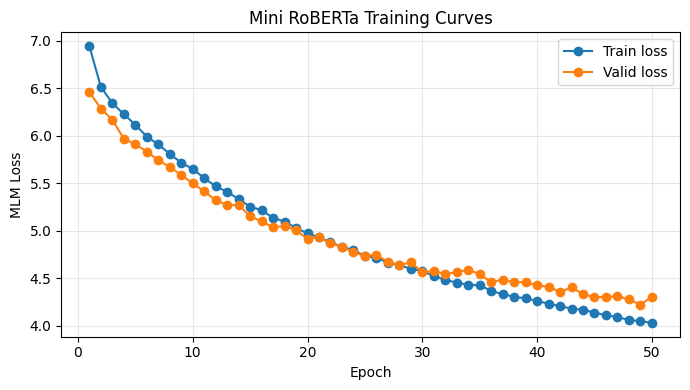

In [27]:
import matplotlib.pyplot as plt

epochs_axis = list(range(1, len(history["train_loss"]) + 1))

plt.figure(figsize=(7, 4))
plt.plot(epochs_axis, history["train_loss"], marker="o", label="Train loss")
plt.plot(epochs_axis, history["valid_loss"], marker="o", label="Valid loss")
plt.xlabel("Epoch")
plt.ylabel("MLM Loss")
plt.title("Mini RoBERTa Training Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 14: Run a simple masked-token prediction demo

To verify behavior qualitatively, the next cell masks one token in a sentence and asks the trained model for top-k predictions at the masked position.

In [29]:
@torch.no_grad()
def predict_mask(
    model: nn.Module,
    sentence: str,
    token_to_id: Dict[str, int],
    id_to_token: Dict[int, str],
    max_length: int,
    top_k: int = 5,
 ) -> None:
    """
    Predict top-k candidates for a single <mask> token in a sentence.
    """
    model.eval()

    # Make sure <mask> is preserved as one token for our simple tokenizer.
    placeholder = "masktokplaceholder"
    normalized = sentence.lower().replace("<mask>", f" {placeholder} ")

    # Tokenize and then convert placeholder back to the special mask token.
    raw_tokens = basic_tokenize(normalized)
    raw_tokens = [MASK_TOKEN if tok == placeholder else tok for tok in raw_tokens]
    tokens = [BOS_TOKEN] + raw_tokens + [EOS_TOKEN]

    # Convert tokens to IDs.
    ids = [token_to_id.get(tok, UNK_ID) for tok in tokens]
    ids = ids[:max_length]
    if len(ids) < max_length:
        ids += [PAD_ID] * (max_length - len(ids))

    input_ids = torch.tensor([ids], dtype=torch.long, device=device)
    attention_mask = (input_ids != PAD_ID).long()

    # Find the first mask position.
    mask_positions = (input_ids[0] == MASK_ID).nonzero(as_tuple=False)
    if len(mask_positions) == 0:
        print("No <mask> token found in input sentence.")
        return
    mask_pos = mask_positions[0].item()

    # Forward pass and top-k extraction at mask position.
    logits, _ = model(input_ids=input_ids, attention_mask=attention_mask, labels=None)
    probs = torch.softmax(logits[0, mask_pos], dim=-1)
    top_probs, top_ids = torch.topk(probs, k=top_k)

    print("Input:", sentence)
    print("Top predictions for <mask>:")
    for rank, (tok_id, prob) in enumerate(zip(top_ids.tolist(), top_probs.tolist()), start=1):
        print(f"{rank}. {id_to_token.get(tok_id, UNK_TOKEN)} ({prob:.4f})")


# Multiple demo sentences for inferencing.
demo_sentences = [
    "the company reported <mask> earnings this quarter .",
    "the government announced a new <mask> policy today .",
    "the team won the <mask> after a close match .",
    "scientists discovered a new <mask> in the galaxy .",
    "stock markets opened <mask> this morning .",
    "the movie received <mask> reviews from critics .",
    "the smartphone includes a <mask> camera system .",
    "the university released <mask> admissions results .",
]

for demo_sentence in demo_sentences:
    print("-" * 90)
    predict_mask(
        model=model,
        sentence=demo_sentence,
        token_to_id=token_to_id,
        id_to_token=id_to_token,
        max_length=cfg.max_length,
        top_k=8,
    )

------------------------------------------------------------------------------------------
Input: the company reported <mask> earnings this quarter .
Top predictions for <mask>:
1. revenue (0.0872)
2. posts (0.0561)
3. quarterly (0.0537)
4. its (0.0277)
5. earnings (0.0236)
6. the (0.0193)
7. 2q (0.0186)
8. a (0.0185)
------------------------------------------------------------------------------------------
Input: the government announced a new <mask> policy today .
Top predictions for <mask>:
1. reserve (0.0439)
2. audit (0.0319)
3. <unk> (0.0310)
4. referendum (0.0280)
5. legal (0.0277)
6. vote (0.0266)
7. bird (0.0206)
8. appeals (0.0205)
------------------------------------------------------------------------------------------
Input: the team won the <mask> after a close match .
Top predictions for <mask>:
1. <unk> (0.1006)
2. season (0.0483)
3. olympics (0.0273)
4. way (0.0192)
5. games (0.0167)
6. spotlight (0.0162)
7. world (0.0131)
8. race (0.0114)
-----------------------------